# 3 Simulación Estocástica

## La base de la simulación estocástica es la generación de números aleatorios. En la práctica se manejan números psudoaleatorios generados a partir de un generador congruencial:

\begin{align}
x_n=(ax_{n-1}+c)\quad	 mod \quad	 m
\end{align}
## con $x_0$, conocido, denominado semilla (seed).

##  Referencia: Ross, S. M. (2023). Simulation. Academic Press.

In [1]:
def generador(semilla, a, c, m, N):

    pseudo = []
    x = semilla

    for _ in range(N):
        x = (a * x + c) % m
        pseudo.append(x)

    return pseudo

In [5]:
semilla = 1234
a = 5**5
c = 12345
m = 2**35-31
N = 10

aleatorio=generador(semilla, a, c, m, N)
print(aleatorio)

[3868595, 12089371720, 17934204982, 3657353448, 21796409461, 12778194036, 5840427251, 6314114773, 9118872532, 12253593472]


In [6]:
[x/m for x in aleatorio]

[0.00011259093308734937,
 0.3518470251847541,
 0.5219540616433537,
 0.10644299476697729,
 0.6343590060908211,
 0.37189439310251987,
 0.16997880466134938,
 0.18376492600354577,
 0.26539412036733756,
 0.356626507216582]

En Python se cuenta con una libreria denominada $\textbf{random}$.

https://docs.python.org/es/3/library/random.html

Veamos algunos ejemplos:

In [7]:
import random

[random.random() for _ in range(10)]

[0.20049059682673553,
 0.7083969612158016,
 0.3897166233081224,
 0.18957744453417458,
 0.3878872602829737,
 0.9469356473979667,
 0.31992001281463933,
 0.9803482722243622,
 0.03746991230405616,
 0.1852831635322012]

### La elección de la semilla al generar números pseudoaleatorios permite obtener secuencias reproducibles y controlables. 

In [12]:
random.seed(42)
random.random()

0.6394267984578837

In [13]:
[random.uniform(0,3) for _ in range(10)]

[0.07503226566800081,
 0.8250879551073578,
 0.6696322144464683,
 2.209413642492037,
 2.030098462268734,
 2.6765387031145362,
 0.26081649788824846,
 1.2657654590558112,
 0.08939165831421103,
 0.6559139244108101]

## $\textbf{Ejemplo}$ Estimación de $\pi$.

### Supongamos que el vector aleatorio $(X,Y)$ está uniformemente distribuido en el cuadrado de área 4 centrado en el origen. Consideremos ahora la probabilidad de que este punto aleatorio del cuadrado esté contenido en el círculo inscrito de radio 1

<img src= circulo.png>

3.14716


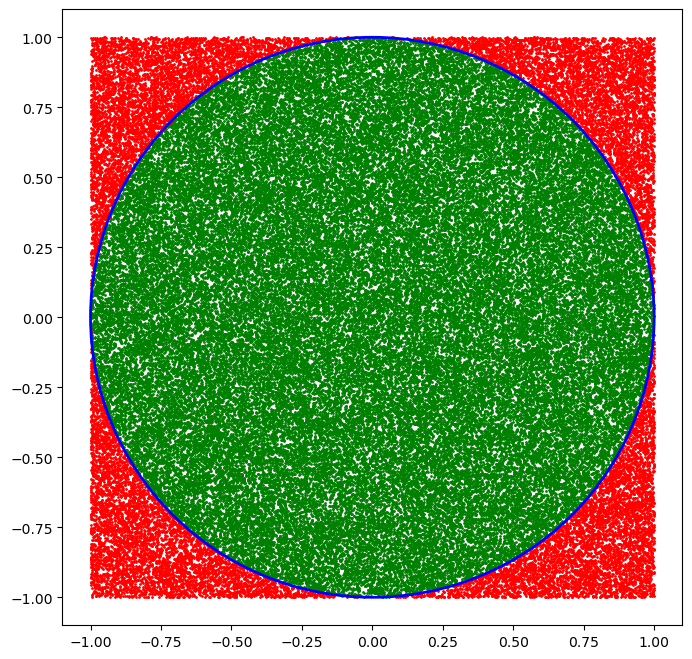

In [19]:
import random
import matplotlib.pyplot as plt

def lanzar_dardo():
    x = random.uniform(-1, 1)
    y = random.uniform(-1, 1)
    return x, y

def dentro(x, y):
    return x**2 + y**2 <= 1


lanzamientos = 100000
dardos_dentro = 0

x_dentro = []
y_dentro = []
x_fuera = []
y_fuera = []

for _ in range(lanzamientos):
    x, y = lanzar_dardo()
    if dentro(x, y):
        dardos_dentro += 1
        x_dentro.append(x)
        y_dentro.append(y)
    else:
        x_fuera.append(x)
        y_fuera.append(y)

pi_estimado = 4 * (dardos_dentro / lanzamientos)
print(pi_estimado)

plt.figure(figsize=(8, 8))
plt.scatter(x_dentro, y_dentro, color='green', s=1)
plt.scatter(x_fuera, y_fuera, color='red', s=1)
circulo = plt.Circle((0,0), 1, color='blue', fill=False, linewidth = 2)
plt.gca().add_patch(circulo)
plt.show()

### $\textbf{Ejercicio}$ Calcular por simulación el valor de la siguiente integral: $$ \int_{-2}^{2}e^{x+x^2}dx$$

la idea es con números aleatorios uniformes \
cambio de variable \
(a,b) a (0,1), y=(x-a)/(b-a) \
x=y(b-a)+a \
dy=(dx)/(b-a)

## 3.1 Simulación de Variables Aleatorias

### Iniciemos en el caso de variables aleatorias discretas y enfoquemonos en el método de la transformada inversa. Considere una v.a. $X$ discreta cuyo rango es $\{x_0, x_1, \ldots\}$.

### cuyas distribuciones de probabilidad de masa son: $\mathbb{P}(X=x_i)=p_i$, $i=0,1,\ldots$.

### Generamos un valor aleatorio $U\sim Unif(0,1)$:

<img src="Xsim.png">

## $\textbf{Ejemplo}$ Simulación de una Bernoulli de parametro $p$.

In [31]:
import random

def generar_bernoulli(p):
    if random.random() < 1-p:
        return 0
    else:
        return 1

generar_bernoulli(0.8)

1

In [35]:
[generar_bernoulli(0.7) for _ in range(10)]

[1, 1, 0, 1, 1, 0, 0, 1, 1, 0]

$\textbf{Ejemplo}$ Generar una Binomial de parámetros $n$ y $p$:

In [40]:
def simular_binomial(n, p):
    exitos = 0
    for _ in range(n):
        exitos += generar_bernoulli(p)
    return exitos
    
simular_binomial(30, 0.3)

5

In [51]:
import numpy as np
res = [simular_binomial(10,0.7) for _ in range(10)]
np.mean(res)

7.4

En el caso continuo, veamos lo correspondiente al caso de una variable aleatoria Exponencial de parámetro $\beta$.

$F(x)=1-e^{-\frac{x}{\beta}}, x\in \mathbb{R}$.

De este modo, un código para generar una exponencial es el siguiente:

In [52]:
import numpy as np

def generar_sim_exponencial(b, N):
    muestra_exponencial = []
    for _ in range(N):
        u = random.random()
        x = -b*np.log(1 - u)
        muestra_exponencial.append(x)
    return muestra_exponencial

In [53]:
b = 0.5  
N = 1000  

muestra_expon=generar_sim_exponencial(b, N)
print(muestra_expon[:5])

[0.6194893309713169, 0.8172577000319632, 1.4780863446992343, 0.24504219028042729, 0.13934128665164586]


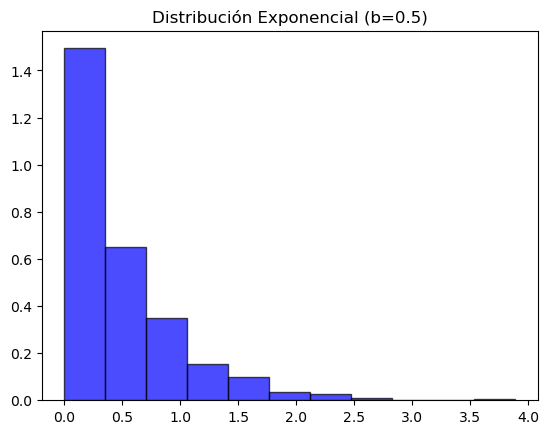

In [61]:
plt.hist(muestra_expon, bins='sturges', density=True, alpha=0.7, color='blue', edgecolor='black')
plt.title(f'Distribución Exponencial (b={b})')
plt.show()

### Random ya tiene implementados su propios generadores, veamos a continuación. 

#### Para generar números aleatorios de valor entero,

In [83]:
random.randint(15, 100)

96

In [86]:
np.random.randint(15,100, size=10) # [15,100) #aquí si se puede generar el arreglo, el de arriba sólo un número

array([81, 57, 24, 94, 32, 92, 74, 89, 57, 23])

## Generar un elemento aleatorio de una secuencia dada.

In [96]:
cursos = ['probabilidad 1', 'probabilidad 2', 'estadística 1', 'estadística 2', 'procesos estaocásticos 1', 'procesos estocásticos 2']
for _ in range(3):
    print(random.choice(cursos))

estadística 2
procesos estaocásticos 1
estadística 2


In [99]:
secuen=range(1,100)
random.choice(secuen)

38

### sample(sec, num): devuelve num elementos aleatorios de la secuencia sec.

In [102]:
poblacion= [1, 2, 3, 4, 5, 6, 7, 10, 11, 12]
random.sample(poblacion, 5)

[2, 10, 3, 11, 12]

### El método choices() devuelve una lista con el elemento seleccionado aleatoriamente de la secuencia especificada. Puede ponderar la probabilidad de cada resultado con el parámetro pesos (weights).

In [1]:
elementos = ['a', 'b', 'c', 'd', 'e']
pesos = [0.1, 0.2, 0.3, 0.2, 0.2]  
tamano_muestra = 3

random.choices(elementos, weights=pesos, k=tamano_muestra)

NameError: name 'random' is not defined

### $\textbf{Ejercicio}$ encontrar una muestra de tamaño 10 para la v.a. del Ejemplo 2.2.1.

esta en la notebook 2

## Simulación de v.a. Continuas 

En este caso se utiliza la libreria: Statistical functions (scipy.stats).

https://docs.scipy.org/doc/scipy/reference/stats.html

Por ejemplo para una Binomial:

In [107]:
from scipy.stats import binom

muestra_binomial=binom.rvs(10, 0.3, size=1000000)
print(muestra_binomial)

[4 3 3 ... 0 3 3]


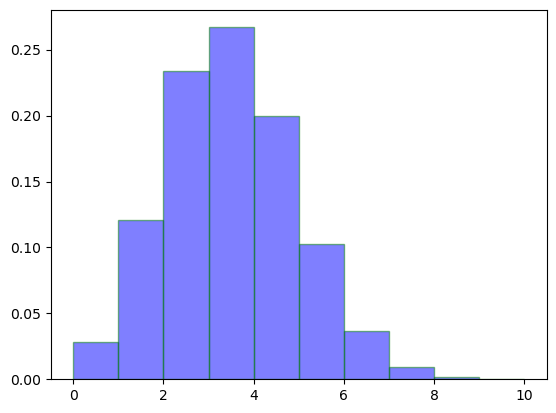

In [109]:
import numpy as np
plt.hist(muestra_binomial, bins=np.arange(0, 11), alpha=0.5, color='blue', edgecolor='green', density=True)
plt.show()

### $\textbf{Ejercicio}$ Realizar las operaciones análogas para la v.a. Poisson.

en lugar de la binomial, la poisson y variar los bins

# 3.2 Teoremas Límite

<img src=conver.png>

## Ley Fuerte de los Grandes Números

### Sean $X_1, X_2, ...$ variables aleatorias i.i.d con media $\mu$. Entonces
### \begin{align}
\frac{X_1+X_2+...+X_n}{n} \longrightarrow^{c.s.} \mu
\end{align}

### “No se puede predecir el comportamiento individual, pero si el comportamiento promedio”

## Ley Debil de los Grandes Números

#### Sean $X_1, X_2,...,$ variables i.i.d con media $\mu$ y varianza $\sigma^2$. Se tiene $$S_n \longrightarrow^\mathbb{P} \mu,$$ cuando $n\rightarrow \infty$.

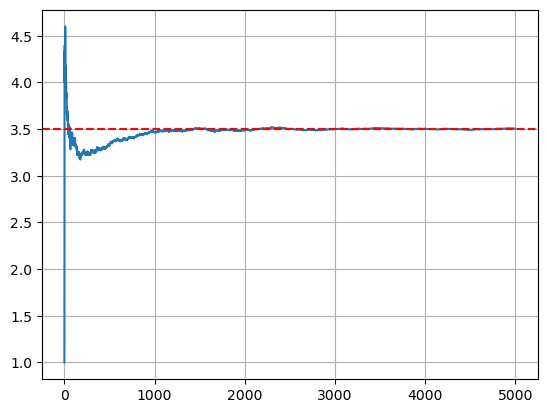

In [113]:
import matplotlib.pyplot as plt

def lanzar_dado():
    return np.random.randint(1, 7)

num_lanzamientos = 5000
resultados = [lanzar_dado() for _ in range(num_lanzamientos)]

media_acumulada = np.cumsum(resultados) / np.arange(1, num_lanzamientos + 1)

plt.plot(np.arange(1, num_lanzamientos + 1), media_acumulada)
plt.axhline(y=3.5, color='r', linestyle='--')
plt.grid(True)
plt.show()

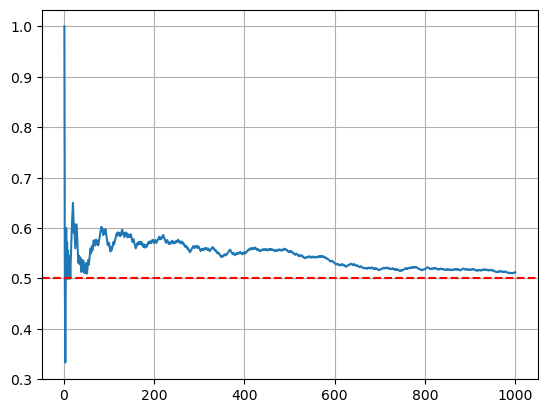

In [114]:
num_lanzamientos = 1000

lanzamientos = np.random.randint(2, size=num_lanzamientos)
proporciones_acumuladas = np.cumsum(lanzamientos) / np.arange(1, num_lanzamientos + 1)

plt.plot(np.arange(1, num_lanzamientos + 1), proporciones_acumuladas)
plt.axhline(y=0.5, color='r', linestyle='--')
plt.grid(True)
plt.show()

## Teorema Central del Límite (TCL)

#### Sean $X_1,X_2,...,$ variables independientes y con la misma distribución de probabilidad tal que $\mathbb{E}[X_i] =\mu$, $Var(X_i) =\sigma^2$ ($i \geq 1$). Entonces, si $S_n=X_1+···+X_n$, se tiene $$\frac{S_{n}-n\mu}{\sigma\sqrt{n}}\longrightarrow ^{\mathcal{D}}Z\sim N(0,1).$$

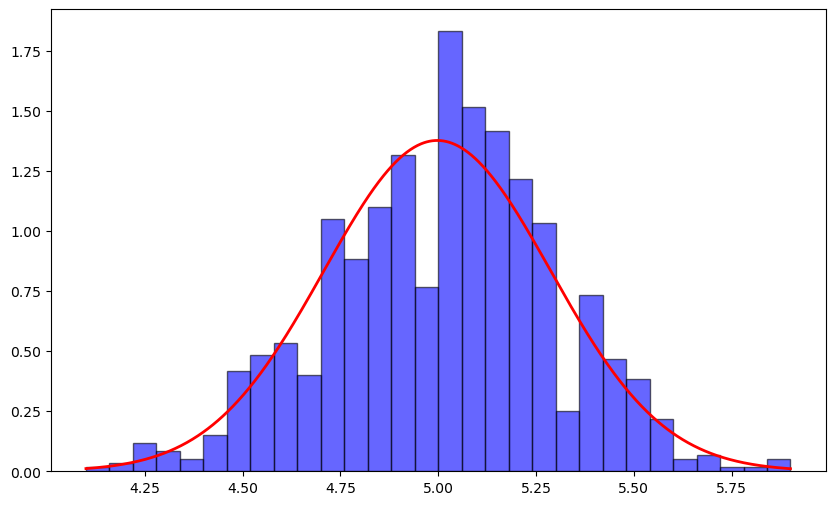

In [115]:
from scipy.stats import norm

numero_muestras = 1000 
tamano_muestra = 30
n_binomial = 10 
p_binomial = 0.5  

poblacion = binom.rvs(n=n_binomial, p=p_binomial, size=100000)
medias_muestrales = [np.mean(random.choices(poblacion, k=tamano_muestra)) for _ in range(numero_muestras)]

media_teorica = np.mean(poblacion)
desviacion_estandar_teorica = np.std(poblacion) / np.sqrt(tamano_muestra) 

plt.figure(figsize=(10, 6))
plt.hist(medias_muestrales, bins=30, density=True, alpha=0.6, color='blue', edgecolor='black')
x = np.linspace(min(medias_muestrales), max(medias_muestrales), 1000)
y = norm.pdf(x, media_teorica, desviacion_estandar_teorica)
plt.plot(x, y, color='red', linewidth=2)
plt.show()

### $\textbf{Ejercicio:}$ La demanda diaria de un producto tiene media 30 y desviación 6. Supuesta la independencia de la demanda de cada día respecto de los restantes: 
### (a) ¿Cuál es la distribución (aproximada) de la demanda en un periodo de 182 días? 
### (b) ¿Cuál es la probabilidad de que en 182 días, el número de unidades demandadas supere 5500 unidades?